In [ ]:
import os, time, json, random, warnings
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import Dataset, DataLoader, Sampler
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")


# ============================================================
# CONFIG
# ============================================================
ROOT = "/content/drive/Shareddrives/Garment Type/Complete_dataset"
OUTDIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
OUTDIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ============================================================
# CHANGES FROM PREVIOUS SCRIPT (SUMMARY)
# ============================================================
# 1. Backbone: convnext_tiny → convnextv2_tiny
# 2. Resolution: 384 → 448
# 3. Added MixUp (alpha=0.2) in Stage 2
# 4. Added HorizontalFlip to base augmentation
# 5. AMP enabled for BOTH Stage 1 and Stage 2
# 6. Val split: 12% → 16%
# 7. Dresses boost: 1.4 → 1.8
# 8. Saves val_split.json for threshold calibration later
# 9. Removed dead ckpt_path code
# ============================================================

# IMAGE SIZE — increased from 384 to 448
IMG_SIZE = 448

# BACKBONE — upgraded to V2
BACKBONE = "convnextv2_tiny"

# TRAINING PARAMS
BATCH = 48              # slightly reduced due to higher resolution
EPOCHS = 100
HEAD_EPOCHS = 8

LR_HEAD = 6e-4
LR_FULL = 1e-4
BACKBONE_LR = 1e-5       # reduced from 2e-5 — less aggressive on pretrained features
HEAD_LR = 1.5e-4        # reduced from 2e-4
WEIGHT_DECAY = 1e-2

PATIENCE = 15            # more patience since LR drops will happen mid-training
WARMUP_EPOCHS = 5
NUM_WORKERS = 2

MIN_SAMPLES_FOR_BALANCED = 12

# LOSS SETTINGS
LABEL_SMOOTH = 0.05
FOCAL_GAMMA = 2.0

# MIXUP
MIXUP_ALPHA = 0.2
MIXUP_PROB = 0.3         # reduced from 0.5 — less noise, tighter convergence

# VAL SPLIT — increased from 12% to 16%
VAL_RATIO = 0.16

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

UPPER_CLASSES = ["blazer", "jumpers", "shirt", "t-shirt", "dresses", "fleece"]

MINORITY_CLASSES = {"fleece", "dresses"}
MEDIUM_CLASSES = set()  # none for upper


# ============================================================
# FOCAL LOSS + LABEL SMOOTHING
# ============================================================
def focal_loss_with_ls(logits, targets, gamma=2.0, smooth=0.05, weight=None):
    num_classes = logits.shape[1]
    one_hot = F.one_hot(targets, num_classes).float().to(logits.device)
    one_hot = one_hot * (1 - smooth) + smooth / num_classes

    log_probs = F.log_softmax(logits, dim=1)
    probs = torch.exp(log_probs)

    focal_factor = (1 - probs) ** gamma
    loss = -one_hot * focal_factor * log_probs
    loss = loss.sum(dim=1)

    if weight is not None:
        loss = loss * weight[targets]

    return loss.mean()


# ============================================================
# MIXUP FOCAL LOSS (for soft labels from mixup)
# ============================================================
def focal_loss_mixup(logits, targets_a, targets_b, lam, gamma=2.0, smooth=0.05, weight=None):
    """Focal loss for mixup: weighted sum of losses for both targets."""
    loss_a = focal_loss_with_ls(logits, targets_a, gamma, smooth, weight)
    loss_b = focal_loss_with_ls(logits, targets_b, gamma, smooth, weight)
    return lam * loss_a + (1 - lam) * loss_b


# ============================================================
# MIXUP
# ============================================================
def mixup_data(x, y, alpha=0.2):
    """Returns mixed inputs, pairs of targets, and lambda."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    lam = max(lam, 1 - lam)  # ensure lam >= 0.5 so original dominates

    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


# ============================================================
# UTILITIES
# ============================================================
def collect_samples(root, allowed_classes):
    root = Path(root)
    samples = []

    for dataset_dir in root.iterdir():
        if not dataset_dir.is_dir():
            continue
        for cls_dir in dataset_dir.iterdir():
            if not cls_dir.is_dir():
                continue
            cls_name = cls_dir.name.lower()
            if cls_name not in allowed_classes:
                continue
            for img_path in cls_dir.iterdir():
                if img_path.is_file():
                    samples.append((str(img_path), cls_name))

    return samples


# ============================================================
# AUGMENTATIONS — HorizontalFlip added to base aug
# ============================================================
def build_aug(img_size, is_train=True):
    h = w = img_size

    if not is_train:
        return A.Compose([
            A.Resize(h, w),
            A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
            ToTensorV2()
        ])

    return A.Compose([
        A.RandomResizedCrop(
            size=(h, w),
            scale=(0.75, 1.0),
            ratio=(0.75, 1.3),
            p=1.0
        ),
        A.HorizontalFlip(p=0.5),               # <-- NEW: was missing
        A.ShiftScaleRotate(
            shift_limit=0.04,
            scale_limit=0.08,
            rotate_limit=8,
            p=0.6
        ),
        A.ColorJitter(0.2, 0.2, 0.2, 0.05, p=0.6),
        A.GaussianBlur(3, p=0.2),
        A.CoarseDropout(
            max_holes=4,
            max_height=int(h * 0.10),
            max_width=int(w * 0.10),
            p=0.3
        ),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


def build_strong_aug(img_size):
    h = w = img_size
    return A.Compose([
        A.RandomResizedCrop(
            size=(h, w),
            scale=(0.60, 1.0),
            ratio=(0.70, 1.4),
            p=1.0
        ),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.06,
            scale_limit=0.12,
            rotate_limit=12,
            p=0.8
        ),
        A.ColorJitter(0.25, 0.25, 0.25, 0.08, p=0.8),
        A.GaussianBlur(blur_limit=3, p=0.3),
        A.CoarseDropout(
            max_holes=6,
            max_height=int(h * 0.12),
            max_width=int(w * 0.12),
            p=0.4
        ),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


# ============================================================
# DATASET
# ============================================================
class ImgDataset(Dataset):
    def __init__(self, samples, cls2idx, img_size, aug=True):
        self.samples = samples
        self.cls2idx = cls2idx
        self.img_size = img_size
        self.aug = aug

        self.base_aug = build_aug(img_size, is_train=aug)
        self.strong_aug = build_strong_aug(img_size)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        p, c = self.samples[i]

        try:
            img = np.array(Image.open(p).convert("RGB"))
        except:
            img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)

        if self.aug and c in MINORITY_CLASSES:
            data = self.strong_aug(image=img)
        elif self.aug and c in MEDIUM_CLASSES:
            if random.random() < 0.5:
                data = self.strong_aug(image=img)
            else:
                data = self.base_aug(image=img)
        else:
            data = self.base_aug(image=img)

        return data["image"], self.cls2idx[c], p


# ============================================================
# BALANCED SAMPLER
# ============================================================
class BalancedBatchSampler(Sampler):
    def __init__(self, labels, n_cls, n_per):
        self.labels = labels
        self.n_cls = n_cls
        self.n_per = n_per

        self.lab2idx = defaultdict(list)
        for i, l in enumerate(labels):
            self.lab2idx[l].append(i)

        for l in self.lab2idx:
            random.shuffle(self.lab2idx[l])

        self.classes = list(self.lab2idx.keys())
        self.used = {c: 0 for c in self.classes}
        self.num_batches = sum(len(v) for v in self.lab2idx.values()) // (n_cls * n_per)

    def __iter__(self):
        for _ in range(self.num_batches):
            chosen = random.sample(self.classes, self.n_cls)
            batch = []
            for c in chosen:
                st = self.used[c]
                en = st + self.n_per
                if en > len(self.lab2idx[c]):
                    random.shuffle(self.lab2idx[c])
                    st = 0; en = self.n_per
                batch.extend(self.lab2idx[c][st:en])
                self.used[c] = en
            yield batch

    def __len__(self):
        return self.num_batches


# ============================================================
# LOAD DATA
# ============================================================
print("Scanning:", ROOT)

samples = collect_samples(ROOT, set(UPPER_CLASSES))

class_counts = Counter(c for _, c in samples)
print("\n=== TOTAL IMAGE COUNT PER CLASS ===")
for cls, cnt in class_counts.most_common():
    print(f"  {cls:20s} : {cnt}")
print(f"  {'TOTAL':20s} : {len(samples)}")

# Train/Val split — 16% val, stratified
by_class = defaultdict(list)
for p, c in samples:
    by_class[c].append((p, c))

train_samples = []
val_samples = []
rng = random.Random(SEED)

for c, arr in by_class.items():
    arr = list(arr)
    rng.shuffle(arr)
    nval = max(2, int(len(arr) * VAL_RATIO))  # at least 2 per class
    val_samples += arr[:nval]
    train_samples += arr[nval:]

print(f"\nTrain: {len(train_samples)}  Val: {len(val_samples)}")

# ============================================================
# SAVE VALIDATION SPLIT — for threshold calibration later
# ============================================================
val_split_info = [{"path": p, "label": c} for p, c in val_samples]
val_split_path = OUTDIR / "val_split.json"
with open(val_split_path, "w") as f:
    json.dump(val_split_info, f, indent=2)
print(f"Val split saved to: {val_split_path}  ({len(val_samples)} samples)")


# ============================================================
# TRAIN
# ============================================================
def train_upper():
    cls2idx = {c: i for i, c in enumerate(sorted(UPPER_CLASSES))}
    print(f"\nClasses: {cls2idx}")

    tr = train_samples
    vl = val_samples

    cnt = Counter([c for _, c in tr])
    print("Train counts:", dict(cnt))

    labels = [c for _, c in tr]

    # --- Balanced sampler ---
    if all(cnt[c] >= MIN_SAMPLES_FOR_BALANCED for c in cnt):
        ncls = min(len(UPPER_CLASSES), 6)
        nper = max(2, BATCH // ncls)
        sampler = BalancedBatchSampler(labels, ncls, nper)
        tr_ds = ImgDataset(tr, cls2idx, IMG_SIZE, aug=True)
        tr_loader = DataLoader(
            tr_ds,
            batch_sampler=sampler,
            num_workers=2,
            pin_memory=True,
            persistent_workers=False
        )
    else:
        tr_ds = ImgDataset(tr, cls2idx, IMG_SIZE, aug=True)
        weights = [1 / (cnt[c] + 1e-6) for c in labels]
        sampler = torch.utils.data.WeightedRandomSampler(weights, len(weights))
        tr_loader = DataLoader(
            tr_ds,
            batch_size=BATCH,
            sampler=sampler,
            num_workers=2,
            pin_memory=True,
            persistent_workers=False
        )

    vl_ds = ImgDataset(vl, cls2idx, IMG_SIZE, aug=False)
    vl_loader = DataLoader(vl_ds, batch_size=64, shuffle=False, num_workers=2)

    # ============================================================
    # CLASS WEIGHTS
    # ============================================================
    class_w = torch.ones(len(cls2idx), device=DEVICE)

    for cls, idx in cls2idx.items():
        n = cnt.get(cls, 0)
        if n > 0:
            class_w[idx] = (1 - 0.9999) / (1 - (0.9999 ** n))
        else:
            class_w[idx] = 1.0

    class_w = class_w / class_w.mean()

    # Branch-specific boosts — dresses increased from 1.4 to 1.8
    boost = {
        "dresses": 1.8,     # <-- increased from 1.4
        "jumpers": 1.2,
    }

    for cls, factor in boost.items():
        if cls in cls2idx:
            class_w[cls2idx[cls]] *= factor

    class_w = class_w / class_w.mean()

    print(f"\nClass weights:")
    for cls in sorted(cls2idx.keys()):
        print(f"  {cls:15s}: {class_w[cls2idx[cls]]:.4f}")

    # ============================================================
    # CREATE MODEL — ConvNeXt V2
# ============================================================
    print(f"\nBackbone: {BACKBONE}")
    model = timm.create_model(BACKBONE, pretrained=True, num_classes=len(cls2idx)).to(DEVICE)

    # Count params
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params / 1e6:.1f}M")

    scaler = torch.cuda.amp.GradScaler()

    # ============================================================
    # STAGE 1: TRAIN CLASSIFIER HEAD ONLY (with AMP)
    # ============================================================
    print(f"\n--- Stage 1: Head-only training ({HEAD_EPOCHS} epochs) ---")

    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True

    opt = torch.optim.AdamW(
        model.get_classifier().parameters(),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY
    )

    for ep in range(1, HEAD_EPOCHS + 1):
        model.train()
        losses = []

        for xb, yb, _ in tr_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                out = model(xb)
                loss = focal_loss_with_ls(out, yb, gamma=FOCAL_GAMMA, smooth=LABEL_SMOOTH, weight=class_w)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

            losses.append(loss.item())

        print(f"  [head] ep{ep}/{HEAD_EPOCHS}  loss={np.mean(losses):.4f}")

    # ============================================================
    # STAGE 2: FULL FINE-TUNING (with AMP + MixUp)
    # ============================================================
    print(f"\n--- Stage 2: Full fine-tuning ({EPOCHS} epochs, MixUp α={MIXUP_ALPHA}) ---")

    for p in model.parameters():
        p.requires_grad = True

    head_params = list(model.get_classifier().parameters())
    head_ids = set(map(id, head_params))
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]

    opt = torch.optim.AdamW([
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)

    # ReduceLROnPlateau — drops LR when val F1 stalls
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="max",          # monitoring F1 (higher is better)
        factor=0.5,          # halve LR on plateau
        patience=5,          # wait 5 epochs before reducing
        min_lr=1e-7
    )

    best_f1 = -1
    patience_counter = 0

    # Store initial LRs for warmup
    initial_lrs = [g["lr"] for g in opt.param_groups]

    # ============================================================
    # CRASH-SAFE RESUMABLE CHECKPOINT (helpers + resume)
    # ============================================================
    import shutil as _shutil
    LAST_CKPT_NAME = "best_upper_cnn_last.pth"

    def _atomic_save(obj, final_path):
        tmp = str(final_path) + ".tmp"
        torch.save(obj, tmp)
        os.replace(tmp, final_path)

    def _save_last(state, name, out_dir):
        local = os.path.join("/content", name)
        _atomic_save(state, local)
        drive = os.path.join(str(out_dir), name)
        if drive.endswith(".pt"):     prev = drive[:-3] + "_prev.pt"
        elif drive.endswith(".pth"):  prev = drive[:-4] + "_prev.pth"
        else:                         prev = drive + "_prev"
        try:
            if os.path.exists(drive):
                try: _shutil.copy2(drive, prev)
                except Exception: pass
            tmp = drive + ".tmp"
            _shutil.copy2(local, tmp)
            os.replace(tmp, drive)
        except Exception as e:
            print(f"  [last-ckpt] Drive copy failed (local copy still safe): {e}")

    def _try_load_last(name, out_dir):
        if name.endswith(".pt"):     prev = name[:-3] + "_prev.pt"
        elif name.endswith(".pth"):  prev = name[:-4] + "_prev.pth"
        else:                        prev = name + "_prev"
        for p in [os.path.join("/content", name),
                  os.path.join(str(out_dir), name),
                  os.path.join(str(out_dir), prev)]:
            if not os.path.exists(p): continue
            try:
                ck = torch.load(p, map_location="cpu", weights_only=False)
                _ = ck["epoch"]; _ = ck["model_state"]; _ = ck["optimizer"]
                print(f"  [resume] found checkpoint at {p} (epoch {ck['epoch']})")
                return ck
            except Exception as e:
                print(f"  [resume] corrupt ckpt at {p}: {e}")
        print("  [resume] no resume checkpoint — starting fresh.")
        return None

    # --- Try to resume previous training run ---
    start_ep = 1
    _resume = _try_load_last(LAST_CKPT_NAME, OUTDIR)
    if _resume is not None:
        model.load_state_dict(_resume["model_state"])
        opt.load_state_dict(_resume["optimizer"])
        try: sched.load_state_dict(_resume["scheduler"])
        except Exception as _e: print(f"  [resume] scheduler restore skipped: {_e}")
        try: scaler.load_state_dict(_resume["scaler"])
        except Exception as _e: print(f"  [resume] scaler restore skipped: {_e}")
        start_ep         = _resume["epoch"] + 1
        best_f1          = _resume.get("best_f1", best_f1)
        patience_counter = _resume.get("patience_counter", 0)
        if "rng_torch"  in _resume:
            try: torch.set_rng_state(_resume["rng_torch"])
            except Exception: pass
        if "rng_numpy"  in _resume:
            try: np.random.set_state(_resume["rng_numpy"])
            except Exception: pass
        if "rng_python" in _resume:
            try: random.setstate(_resume["rng_python"])
            except Exception: pass
        if "rng_cuda"   in _resume and torch.cuda.is_available() and _resume["rng_cuda"] is not None:
            try: torch.cuda.set_rng_state_all(_resume["rng_cuda"])
            except Exception: pass
        print(f"  [resume] best_f1={best_f1:.4f}, patience={patience_counter}, next_ep={start_ep}")
        del _resume

    for ep in range(start_ep, EPOCHS + 1):
        model.train()
        losses = []
        n_mixup = 0

        for xb, yb, _ in tr_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                # MixUp with probability MIXUP_PROB
                if random.random() < MIXUP_PROB:
                    xb_mixed, ya, yb_mix, lam = mixup_data(xb, yb, alpha=MIXUP_ALPHA)
                    out = model(xb_mixed)
                    loss = focal_loss_mixup(
                        out, ya, yb_mix, lam,
                        gamma=FOCAL_GAMMA, smooth=LABEL_SMOOTH, weight=class_w
                    )
                    n_mixup += 1
                else:
                    out = model(xb)
                    loss = focal_loss_with_ls(
                        out, yb, gamma=FOCAL_GAMMA, smooth=LABEL_SMOOTH, weight=class_w
                    )

            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            losses.append(loss.item())

        # LR schedule: warmup then plateau-based
        if ep <= WARMUP_EPOCHS:
            scale = ep / float(WARMUP_EPOCHS)
            for g, init_lr in zip(opt.param_groups, initial_lrs):
                g["lr"] = init_lr * scale
        else:
            sched.step(f1)  # plateau scheduler watches val F1

        # ============================================================
        # VALIDATION
        # ============================================================
        model.eval()
        y_true = []
        y_pred = []
        all_logits = []

        with torch.no_grad():
            for xb, yb, _ in vl_loader:
                xb = xb.to(DEVICE, non_blocking=True)

                with torch.cuda.amp.autocast():
                    logits = model(xb)

                preds = logits.argmax(1).cpu().numpy()
                y_pred += preds.tolist()
                y_true += yb.numpy().tolist()
                all_logits.append(logits.cpu())

        f1 = f1_score(y_true, y_pred, average="macro")
        acc = accuracy_score(y_true, y_pred)
        cur_lr = opt.param_groups[0]["lr"]

        print(f"  [full] ep{ep}/{EPOCHS}  loss={np.mean(losses):.4f}  "
              f"f1={f1:.4f}  acc={acc:.4f}  lr={cur_lr:.2e}  "
              f"mixup_batches={n_mixup}")

        if f1 > best_f1:
            best_f1 = f1
            patience_counter = 0

            torch.save({
                "model_state": model.state_dict(),
                "classes": sorted(cls2idx.keys()),
                "branch": "upper",
                "backbone": BACKBONE,
                "img_size": IMG_SIZE,
                "best_f1": best_f1,
            }, OUTDIR / "best_upper_cnn.pth")

            # Also save validation logits for threshold calibration
            all_logits_cat = torch.cat(all_logits, dim=0)
            all_probs = torch.softmax(all_logits_cat, dim=1).numpy()
            np.savez(
                OUTDIR / "val_predictions.npz",
                y_true=np.array(y_true),
                y_pred=np.array(y_pred),
                probs=all_probs,
                classes=sorted(cls2idx.keys())
            )

            print(f"  ✓ Saved BEST model (f1={best_f1:.4f}) + val predictions")
        else:
            patience_counter += 1

        # --- Save resumable "last" checkpoint every epoch ---
        _last_state = {
            "epoch": ep,
            "model_state": model.state_dict(),
            "optimizer": opt.state_dict(),
            "scheduler": sched.state_dict(),
            "scaler": scaler.state_dict(),
            "best_f1": best_f1,
            "patience_counter": patience_counter,
            "rng_torch": torch.get_rng_state(),
            "rng_cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            "rng_numpy": np.random.get_state(),
            "rng_python": random.getstate(),
        }
        _save_last(_last_state, LAST_CKPT_NAME, OUTDIR)
        del _last_state

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at ep{ep} (patience={PATIENCE})")
            break

    # ============================================================
    # FINAL REPORT
    # ============================================================
    print(f"\n{'='*60}")
    print(f"  TRAINING COMPLETE — Best F1: {best_f1:.4f}")
    print(f"{'='*60}")

    rep = classification_report(y_true, y_pred, target_names=sorted(cls2idx.keys()), digits=4)
    print(rep)

    (OUTDIR / "upper_cnn_report.txt").write_text(rep)
    np.save(OUTDIR / "upper_cnn_cm.npy", confusion_matrix(y_true, y_pred))

    # ============================================================
    # COMPUTE THRESHOLDS FROM BEST VAL PREDICTIONS
    # ============================================================
    print("\n--- Computing per-class thresholds from validation set ---")

    val_data = np.load(OUTDIR / "val_predictions.npz", allow_pickle=True)
    vt = val_data["y_true"]
    vp = val_data["y_pred"]
    vprobs = val_data["probs"]
    classes = list(val_data["classes"])

    thresholds = {}
    stats = {}
    TARGET_PRECISION = 0.90

    for cls_idx, cls_name in enumerate(classes):
        mask = (vp == cls_idx)
        n_total = mask.sum()

        if n_total < 5:
            thresholds[cls_name] = 0.95
            stats[cls_name] = {"threshold": 0.95, "note": f"Too few predictions ({n_total})"}
            continue

        pred_conf = vprobs[mask, cls_idx]
        pred_correct = (vt[mask] == cls_idx)

        best_t = 0.95
        for t in np.arange(0.20, 0.99, 0.01):
            above = pred_conf >= t
            if above.sum() == 0:
                continue
            precision = pred_correct[above].sum() / above.sum()
            if precision >= TARGET_PRECISION:
                best_t = round(float(t), 2)
                break

        thresholds[cls_name] = best_t
        n_accepted = int((pred_conf >= best_t).sum())
        stats[cls_name] = {
            "threshold": best_t,
            "n_accepted": n_accepted,
            "n_rejected": int(n_total) - n_accepted,
            "n_total": int(n_total),
            "rejection_rate": round((int(n_total) - n_accepted) / max(int(n_total), 1), 4)
        }

    print(f"\n  {'Class':<15s} {'Threshold':>10s} {'Accept':>8s} {'Reject':>8s} {'Rej%':>8s}")
    print(f"  {'-'*50}")
    for cls_name in classes:
        s = stats[cls_name]
        rej = f"{s.get('rejection_rate', 0)*100:.1f}%" if 'rejection_rate' in s else "N/A"
        acc = s.get('n_accepted', 'N/A')
        rej_n = s.get('n_rejected', 'N/A')
        print(f"  {cls_name:<15s} {s['threshold']:>10.2f} {acc:>8} {rej_n:>8} {rej:>8s}")

    thresh_path = OUTDIR / "upper_per_class_thresholds.json"
    with open(thresh_path, "w") as f:
        json.dump({"thresholds": thresholds, "calibration_stats": stats}, f, indent=2)
    print(f"\n  Thresholds saved to: {thresh_path}")

    return best_f1


# ============================================================
# RUN
# ============================================================
best_f1 = train_upper()

summary = {
    "backbone": BACKBONE,
    "img_size": IMG_SIZE,
    "best_f1": best_f1,
    "mixup_alpha": MIXUP_ALPHA,
    "val_ratio": VAL_RATIO,
}
(OUTDIR / "summary.json").write_text(json.dumps(summary, indent=2))
print(f"\nDONE. All outputs saved in: {OUTDIR}")

In [ ]:
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model


def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # Dummy input
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)

    # Export
    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
    )

    # Validate
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    return onnx_path


def validate_onnx(model, cfg):
    """Compare PyTorch vs ONNX Runtime outputs."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    # PyTorch inference
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    with torch.no_grad():
        pt_logits = model(dummy).cpu().numpy()

    # ONNX Runtime inference
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)
    ort_logits = session.run(
        ["logits"],
        {"input": dummy.cpu().numpy()}
    )[0]

    # Compare
    max_diff = np.abs(pt_logits - ort_logits).max()
    mean_diff = np.abs(pt_logits - ort_logits).mean()
    pt_pred = pt_logits.argmax(1)
    ort_pred = ort_logits.argmax(1)
    preds_match = (pt_pred == ort_pred).all()

    print(f"  Max  abs diff: {max_diff:.8f}")
    print(f"  Mean abs diff: {mean_diff:.8f}")
    print(f"  Predictions match: {preds_match}")

    if max_diff < 1e-4:
        print(f"  ✓ Outputs match within tolerance")
    else:
        print(f"  ⚠ Outputs differ beyond 1e-4 — check model")

    return session


def benchmark_onnx(cfg, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(1, 3, img_size, img_size).astype(np.float32)

    # Warmup
    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    # Benchmark
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
          f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}")
    print(f"  Throughput: ~{1000/times.mean():.0f} img/s (batch=1)")

    return times

In [ ]:
print("=" * 60)
print("  UPPER V3 — ConvNeXt-V2-Tiny (448px)")
print("=" * 60)

cfg = MODELS["upper_v3"]
upper_model = load_pytorch_model(cfg)
print()
export_to_onnx(upper_model, cfg, opset=OPSET)
print()
validate_onnx(upper_model, cfg)
print()
benchmark_onnx(cfg)

In [ ]:
import os
import json
import time
import numpy as np
from pathlib import Path

import torch
import torch.nn.functional as F
import timm
import onnx
import onnxruntime as ort

# ============================================================
# PATHS & CONFIGURATION
# ============================================================
UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run") # Placeholder, not used in this example

MODELS = {
    "upper_v3": {
        "model_name": "upper_v3", # Added for clarity in print statements
        "ckpt": UPPER_DIR / "best_upper_cnn.pth",
        "backbone": "convnextv2_tiny",
        "img_size": 448,
        "classes": ["blazer", "dresses", "fleece", "jumpers", "shirt", "t-shirt"],
        "onnx_out": UPPER_DIR / "upper_v3.onnx",
        "thresholds": UPPER_DIR / "upper_per_class_thresholds.json",
    }
}

OPSET = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Verify all checkpoints exist
print("Checking model paths:")
for name, cfg in MODELS.items():
    assert cfg["ckpt"].exists(), f"Missing checkpoint: {cfg['ckpt']}"
    print(f"✓ {name}: {cfg['ckpt'].name} ({cfg['backbone']}, {cfg['img_size']}px, {len(cfg['classes'])} classes)")

# ============================================================
# MODEL LOADING, EXPORT, VALIDATION, AND BENCHMARK FUNCTIONS
# ============================================================
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model


def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # Dummy input
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)

    # Export
    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
    )

    # Validate ONNX file structure
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    return onnx_path


def validate_onnx(model, cfg):
    """Compare PyTorch vs ONNX Runtime outputs."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    # PyTorch inference
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    with torch.no_grad():
        pt_logits = model(dummy).cpu().numpy()

    # ONNX Runtime inference
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)
    ort_logits = session.run(
        ["logits"],
        {"input": dummy.cpu().numpy()}
    )[0]

    # Compare
    max_diff = np.abs(pt_logits - ort_logits).max()
    mean_diff = np.abs(pt_logits - ort_logits).mean()
    pt_pred = pt_logits.argmax(1)
    ort_pred = ort_logits.argmax(1)
    preds_match = (pt_pred == ort_pred).all()

    print(f"  Max  abs diff: {max_diff:.8f}")
    print(f"  Mean abs diff: {mean_diff:.8f}")
    print(f"  Predictions match: {preds_match}")

    if max_diff < 1e-4:
        print(f"  ✓ Outputs match within tolerance")
    else:
        print(f"  ⚠ Outputs differ beyond 1e-4 — check model")

    return session


def benchmark_onnx(cfg, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(1, 3, img_size, img_size).astype(np.float32)

    # Warmup
    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    # Benchmark
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
          f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}")
    print(f"  Throughput: ~{1000/times.mean():.0f} img/s (batch=1)")

    return times


# ============================================================
# EXECUTION BLOCK (Upper V3 Model)
# ============================================================
print("\n" + "=" * 60)
print("  UPPER V3 — ConvNeXt-V2-Tiny (448px) - ONNX Export & Validation")
print("=" * 60)

cfg = MODELS["upper_v3"]

print(f"\nLoading PyTorch model for {cfg['model_name']} from: {cfg['ckpt']}")
upper_model = load_pytorch_model(cfg)

print(f"\nExporting {cfg['model_name']} model to ONNX...")
export_to_onnx(upper_model, cfg, opset=OPSET)

print(f"\nValidating ONNX output for {cfg['model_name']}...")
validate_onnx(upper_model, cfg)

print(f"\nBenchmarking ONNX Runtime for {cfg['model_name']}...")
benchmark_onnx(cfg)

print("\n" + "=" * 60)
print("  All ONNX export, validation, and benchmarking complete!")
print("=" * 60)


In [ ]:
import os
import json
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# CONFIG
# ============================================================
# --- TEST SETS ---
TEST_ROOT_1 = Path("/content/drive/Shareddrives/Garment Type/classified_images_13_14_test/13_14th_test")
TEST_ROOT_2 = Path("/content/drive/Shareddrives/Garment Type/Careys_labelled_data/to_test")

# --- MODEL ---
MODEL_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
CKPT_PATH = MODEL_DIR / "best_upper_cnn.pth"
THRESH_PATH = MODEL_DIR / "upper_per_class_thresholds.json"

OUTDIR = MODEL_DIR / "inference_results"
OUTDIR.mkdir(exist_ok=True, parents=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# These must match training
IMG_SIZE = 448
BACKBONE = "convnextv2_tiny"


# ============================================================
# PREPROCESS
# ============================================================
def build_infer_aug(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


# ============================================================
# LOAD MODEL
# ============================================================
def load_model():
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    classes = ckpt["classes"]

    model = timm.create_model(
        BACKBONE,
        pretrained=False,
        num_classes=len(classes)
    ).to(DEVICE)

    model.load_state_dict(ckpt["model_state"], strict=True)
    model.eval()

    print(f"Loaded: {CKPT_PATH.name}")
    print(f"Backbone: {BACKBONE}, Resolution: {IMG_SIZE}")
    print(f"Classes: {classes}")
    print(f"Best F1 (train): {ckpt.get('best_f1', 'N/A')}")

    return model, classes


# ============================================================
# LOAD THRESHOLDS
# ============================================================
def load_thresholds():
    if THRESH_PATH.exists():
        with open(THRESH_PATH) as f:
            data = json.load(f)
        thresholds = data["thresholds"]
        print(f"\nPer-class thresholds loaded:")
        for cls, t in thresholds.items():
            print(f"  {cls:<15s}: {t:.2f}")
        return thresholds
    else:
        print(f"\nWARNING: No threshold file found at {THRESH_PATH}")
        print("Running without rejection.")
        return None


# ============================================================
# COLLECT TEST SAMPLES
# ============================================================
def collect_test_samples(test_root):
    samples = []
    upper_dir = test_root / "upper"
    if not upper_dir.exists():
        print(f"WARNING: {upper_dir} not found, skipping.")
        return samples

    for cls in sorted(os.listdir(upper_dir)):
        cls_dir = upper_dir / cls
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.iterdir():
            if img.is_file():
                samples.append((str(img), cls.lower()))

    return samples


# ============================================================
# INFERENCE
# ============================================================
def infer_on_samples(samples, model, classes, aug):
    cls2idx = {c.lower(): i for i, c in enumerate(classes)}
    y_true, y_pred = [], []
    all_probs = []

    with torch.no_grad():
        for path, gt in tqdm(samples):
            try:
                img_pil = Image.open(path).convert("RGB")
                img_np = np.array(img_pil)
            except:
                print(f"  Skipping corrupt image: {path}")
                continue

            x = aug(image=img_np)["image"].unsqueeze(0).to(DEVICE)

            with torch.cuda.amp.autocast():
                logits = model(x)[0]

            probs = torch.softmax(logits, dim=0).cpu().numpy()
            pred = probs.argmax()

            if gt.lower() not in cls2idx:
                print(f"  Skipping unknown GT class: {gt}")
                continue

            y_true.append(cls2idx[gt.lower()])
            y_pred.append(pred)
            all_probs.append(probs)

    return np.array(y_true), np.array(y_pred), np.array(all_probs)


# ============================================================
# APPLY THRESHOLDS
# ============================================================
def apply_thresholds(y_true, y_pred, probs, classes, thresholds):
    final_preds = []
    decisions = []

    for i in range(len(y_pred)):
        top_idx = y_pred[i]
        top_conf = probs[i, top_idx]
        top_class = classes[top_idx]

        if top_conf >= thresholds.get(top_class, 0.5):
            final_preds.append(top_idx)
            decisions.append("confident")
        else:
            final_preds.append(-1)
            decisions.append("rejected")

    return np.array(final_preds), np.array(decisions)


# ============================================================
# PLOTTING
# ============================================================
def plot_confusion_matrix(cm, classes, title, save_path=None):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


# ============================================================
# REPORT WITH REJECTION
# ============================================================
def report_with_rejection(y_true, final_preds, decisions, classes, title=""):
    n_total = len(y_true)
    n_rejected = (final_preds == -1).sum()
    n_accepted = n_total - n_rejected

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Total:    {n_total}")
    print(f"  Accepted: {n_accepted}  ({n_accepted/n_total*100:.1f}%)")
    print(f"  Rejected: {n_rejected}  ({n_rejected/n_total*100:.1f}%)")

    for d in ["confident", "rejected"]:
        count = (decisions == d).sum()
        print(f"    {d:>12s}: {count:5d}  ({count/n_total*100:.1f}%)")

    accepted_mask = final_preds != -1
    report = ""

    if accepted_mask.sum() > 0:
        acc_true = y_true[accepted_mask]
        acc_pred = final_preds[accepted_mask]
        print(f"\n--- Classification Report (accepted only) ---")
        report = classification_report(
            acc_true, acc_pred, target_names=classes, digits=4, zero_division=0
        )
        print(report)

        acc = (acc_true == acc_pred).sum() / len(acc_true)
        print(f"  Accuracy (accepted): {acc:.4f}")

    all_correct = ((final_preds == y_true) & (final_preds != -1)).sum()
    print(f"  Accuracy (all, rejected=wrong): {all_correct/n_total:.4f}")

    return report


# ============================================================
# RUN ON A SINGLE TEST SET
# ============================================================
def evaluate_test_set(name, test_root, model, classes, aug, thresholds):
    print(f"\n{'#'*60}")
    print(f"  TEST SET: {name}")
    print(f"  Path: {test_root}")
    print(f"{'#'*60}")

    samples = collect_test_samples(test_root)
    if len(samples) == 0:
        print("  No samples found, skipping.")
        return

    print(f"  Found {len(samples)} samples")

    y_true, y_pred, probs = infer_on_samples(samples, model, classes, aug)

    # --- Baseline (no thresholds) ---
    print(f"\n--- BASELINE (no rejection) ---")
    report_base = classification_report(y_true, y_pred, target_names=classes, digits=4)
    print(report_base)

    cm_base = confusion_matrix(y_true, y_pred, labels=list(range(len(classes))))
    plot_confusion_matrix(
        cm_base, classes,
        f"{name} — Baseline (no rejection)",
        save_path=OUTDIR / f"{name}_baseline_cm.png"
    )

    (OUTDIR / f"{name}_baseline_report.txt").write_text(report_base)

    # --- With thresholds ---
    if thresholds:
        final_preds, decisions = apply_thresholds(y_true, y_pred, probs, classes, thresholds)

        report_thresh = report_with_rejection(
            y_true, final_preds, decisions, classes,
            title=f"{name} — With Per-Class Thresholds"
        )

        accepted_mask = final_preds != -1
        if accepted_mask.sum() > 0:
            cm_thresh = confusion_matrix(
                y_true[accepted_mask], final_preds[accepted_mask],
                labels=list(range(len(classes)))
            )
            plot_confusion_matrix(
                cm_thresh, classes,
                f"{name} — With Thresholds (accepted only)",
                save_path=OUTDIR / f"{name}_thresholded_cm.png"
            )

        (OUTDIR / f"{name}_thresholded_report.txt").write_text(str(report_thresh))

        # Save per-sample decisions
        decisions_path = OUTDIR / f"{name}_sample_decisions.csv"
        with open(decisions_path, "w") as f:
            f.write("sample_idx,true_class,raw_pred,final_pred,decision,confidence\n")
            for i in range(len(y_true)):
                true_cls = classes[y_true[i]]
                raw_cls = classes[y_pred[i]]
                final_cls = classes[final_preds[i]] if final_preds[i] != -1 else "REJECTED"
                conf = probs[i, y_pred[i]]
                f.write(f"{i},{true_cls},{raw_cls},{final_cls},{decisions[i]},{conf:.4f}\n")

        print(f"  Per-sample decisions: {decisions_path}")

    return y_true, y_pred, probs


# ============================================================
# MAIN
# ============================================================
print(f"Device: {DEVICE}")

model, classes = load_model()
aug = build_infer_aug(IMG_SIZE)
thresholds = load_thresholds()

# Run on both test sets
r1 = evaluate_test_set("test1_13_14th", TEST_ROOT_1, model, classes, aug, thresholds)
r2 = evaluate_test_set("test2_careys", TEST_ROOT_2, model, classes, aug, thresholds)

# Combined report
if r1 and r2:
    y1_true, y1_pred, p1 = r1
    y2_true, y2_pred, p2 = r2

    y_all_true = np.concatenate([y1_true, y2_true])
    y_all_pred = np.concatenate([y1_pred, y2_pred])
    p_all = np.concatenate([p1, p2])

    print(f"\n{'#'*60}")
    print(f"  COMBINED (both test sets)")
    print(f"{'#'*60}")

    report_combined = classification_report(
        y_all_true, y_all_pred, target_names=classes, digits=4
    )
    print(f"\n--- Baseline Combined ---")
    print(report_combined)

    cm_combined = confusion_matrix(y_all_true, y_all_pred, labels=list(range(len(classes))))
    plot_confusion_matrix(
        cm_combined, classes,
        "Combined — Baseline",
        save_path=OUTDIR / "combined_baseline_cm.png"
    )

    (OUTDIR / "combined_baseline_report.txt").write_text(report_combined)

    if thresholds:
        final_all, dec_all = apply_thresholds(y_all_true, y_all_pred, p_all, classes, thresholds)
        report_with_rejection(
            y_all_true, final_all, dec_all, classes,
            title="Combined — With Per-Class Thresholds"
        )

print(f"\nAll outputs saved in: {OUTDIR}")

In [ ]:
!pip install -q timm onnx onnxruntime-gpu onnxruntime
import os
import json
import time
import numpy as np
from pathlib import Path

import torch
import torch.nn.functional as F
import timm
import onnx
import onnxruntime as ort

print(f"torch         : {torch.__version__}")
print(f"timm          : {timm.__version__}")
print(f"onnx          : {onnx.__version__}")
print(f"onnxruntime   : {ort.__version__}")
print(f"CUDA          : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")

torch         : 2.9.0+cu128
timm          : 1.0.24
onnx          : 1.20.1
onnxruntime   : 1.24.1
CUDA          : True
GPU           : NVIDIA A100-SXM4-80GB


In [ ]:
# ============================================================
# PATHS
# ============================================================
UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "upper_v3": {
        "ckpt": UPPER_DIR / "best_upper_cnn.pth",
        "backbone": "convnextv2_tiny",
        "img_size": 448,
        "classes": ["blazer", "dresses", "fleece", "jumpers", "shirt", "t-shirt"],
        "onnx_out": UPPER_DIR / "upper_v3.onnx",
        "thresholds": UPPER_DIR / "upper_per_class_thresholds.json",
    }
}

OPSET = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Verify all checkpoints exist
for name, cfg in MODELS.items():
    assert cfg["ckpt"].exists(), f"Missing checkpoint: {cfg['ckpt']}"
    print(f"✓ {name}: {cfg['ckpt'].name} ({cfg['backbone']}, {cfg['img_size']}px, {len(cfg['classes'])} classes)")

✓ upper_v3: best_upper_cnn.pth (convnextv2_tiny, 448px, 6 classes)


In [ ]:
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model


def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # Dummy input
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)

    # Export
    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
    )

    # Validate
    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    return onnx_path


def validate_onnx(model, cfg):
    """Compare PyTorch vs ONNX Runtime outputs."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    # PyTorch inference
    dummy = torch.randn(1, 3, img_size, img_size, device=DEVICE)
    with torch.no_grad():
        pt_logits = model(dummy).cpu().numpy()

    # ONNX Runtime inference
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)
    ort_logits = session.run(
        ["logits"],
        {"input": dummy.cpu().numpy()}
    )[0]

    # Compare
    max_diff = np.abs(pt_logits - ort_logits).max()
    mean_diff = np.abs(pt_logits - ort_logits).mean()
    pt_pred = pt_logits.argmax(1)
    ort_pred = ort_logits.argmax(1)
    preds_match = (pt_pred == ort_pred).all()

    print(f"  Max  abs diff: {max_diff:.8f}")
    print(f"  Mean abs diff: {mean_diff:.8f}")
    print(f"  Predictions match: {preds_match}")

    if max_diff < 1e-4:
        print(f"  ✓ Outputs match within tolerance")
    else:
        print(f"  ⚠ Outputs differ beyond 1e-4 — check model")

    return session


def benchmark_onnx(cfg, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]
    onnx_path = str(cfg["onnx_out"])

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(onnx_path, providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(1, 3, img_size, img_size).astype(np.float32)

    # Warmup
    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    # Benchmark
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
          f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}")
    print(f"  Throughput: ~{1000/times.mean():.0f} img/s (batch=1)")

    return times

In [ ]:
print("=" * 60)
print("  LOADING .PT MODEL AND EXPORTING TO ONNX")
print("=" * 60)

# Get the configuration for the 'upper_v3' model, which includes the .pt checkpoint path
cfg = MODELS["upper_v3"]

# Load the PyTorch model from the specified checkpoint path in the configuration
print(f"\nLoading PyTorch model for {cfg['model_name']} from: {cfg['ckpt']}")
upper_model = load_pytorch_model(cfg)

# Export the loaded PyTorch model to ONNX format
print(f"\nExporting {cfg['model_name']} model to ONNX...")
export_to_onnx(upper_model, cfg, opset=OPSET)

print("\nModel loaded and exported to ONNX successfully!")

  UPPER V3 — ConvNeXt-V2-Tiny (448px)


W0211 16:24:41.516000 340 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


  Loaded: convnextv2_tiny — 27.9M params
  Best F1 (train): 0.9083172941361534

  Exporting to: /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper_v3.onnx


W0211 16:24:42.533000 340 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0211 16:24:42.534000 340 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0211 16:24:42.536000 340 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0211 16:24:42.538000 340 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

  ✓ ONNX valid — 0.9 MB
  Opset: 17
  Input:  input  → [batch, 3, 448, 448]
  Output: logits → [batch, 6]

  Max  abs diff: 0.00132269
  Mean abs diff: 0.00059850
  Predictions match: True
  ⚠ Outputs differ beyond 1e-4 — check model

  Active providers: ['CPUExecutionProvider']
  Latency (ms): mean=171.6, median=162.0, p95=198.0, min=152.2, max=201.4
  Throughput: ~6 img/s (batch=1)


array([153.919991, 156.69464 , 154.195764, 154.414436, 155.952907,
       165.284496, 152.895317, 154.378093, 154.287948, 154.246036,
       154.630511, 163.467909, 158.074394, 153.299888, 155.868246,
       154.046581, 154.205075, 157.164919, 167.588807, 153.354243,
       160.457873, 191.222427, 190.705605, 190.344795, 191.882118,
       188.431846, 188.906686, 191.26848 , 196.951353, 200.861427,
       201.396301, 198.835219, 192.937942, 195.293141, 195.103257,
       193.962494, 189.075298, 190.345142, 184.899167, 190.255626,
       188.188677, 190.727949, 159.95435 , 152.576245, 156.638285,
       153.545382, 152.20174 , 166.142373, 154.425572, 153.454889])

In [ ]:
for name, cfg in MODELS.items():
    # Load thresholds if available
    thresholds = {}
    if cfg["thresholds"].exists():
        with open(cfg["thresholds"]) as f:
            tdata = json.load(f)
        thresholds = tdata.get("thresholds", {})

    meta = {
        "model_name": name,
        "backbone": cfg["backbone"],
        "onnx_file": cfg["onnx_out"].name,
        "opset": OPSET,
        "input_name": "input",
        "output_name": "logits",
        "input_shape": [1, 3, cfg["img_size"], cfg["img_size"]],
        "dynamic_batch": True,
        "classes": cfg["classes"],
        "num_classes": len(cfg["classes"]),
        "preprocessing": {
            "resize": [cfg["img_size"], cfg["img_size"]],
            "normalize_mean": [0.485, 0.456, 0.406],
            "normalize_std": [0.229, 0.224, 0.225],
            "channel_order": "RGB",
            "tensor_format": "NCHW",
            "dtype": "float32",
        },
        "thresholds": thresholds,
    }

    meta_path = cfg["onnx_out"].with_suffix(".json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"✓ {name}: {meta_path}")
    print(f"  Classes: {cfg['classes']}")
    print(f"  Thresholds: {thresholds}")
    print()

✓ upper_v3: /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper_v3.json
  Classes: ['blazer', 'dresses', 'fleece', 'jumpers', 'shirt', 't-shirt']
  Thresholds: {'blazer': 0.2, 'dresses': 0.54, 'fleece': 0.2, 'jumpers': 0.2, 'shirt': 0.2, 't-shirt': 0.2}



In [ ]:
print("\n" + "=" * 60)
print("  EXPORT SUMMARY")
print("=" * 60)

for name, cfg in MODELS.items():
    onnx_path = cfg["onnx_out"]
    meta_path = onnx_path.with_suffix(".json")
    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)

    print(f"\n  {name}:")
    print(f"    ONNX:      {onnx_path} ({size_mb:.1f} MB)")
    print(f"    Metadata:  {meta_path}")
    print(f"    Backbone:  {cfg['backbone']}")
    print(f"    Input:     [batch, 3, {cfg['img_size']}, {cfg['img_size']}]")
    print(f"    Classes:   {cfg['classes']}")

print(f"\n{'='*60}")
print("  All exports complete!")
print("="*60)


  EXPORT SUMMARY

  upper_v3:
    ONNX:      /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper_v3.onnx (0.9 MB)
    Metadata:  /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper_v3.json
    Backbone:  convnextv2_tiny
    Input:     [batch, 3, 448, 448]
    Classes:   ['blazer', 'dresses', 'fleece', 'jumpers', 'shirt', 't-shirt']

  All exports complete!


In [ ]:
# ============================================================
# PATHS
# ============================================================
TEST_ROOT_1 = Path("/content/drive/Shareddrives/Garment Type/classified_images_13_14_test/13_14th_test")
TEST_ROOT_2 = Path("/content/drive/Shareddrives/Garment Type/Careys_labelled_data/to_test")
import albumentations as A
from albumentations.pytorch import ToTensorV2
UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "upper_v3": {
        "pt_ckpt": UPPER_DIR / "best_upper_cnn.pth",
        "onnx_path": UPPER_DIR / "upper_v3.onnx",
        "backbone": "convnextv2_tiny",
        "img_size": 448,
        "classes": ["blazer", "dresses", "fleece", "jumpers", "shirt", "t-shirt"],
        "branch_folder": "upper",
    }
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Verify files exist
for name, cfg in MODELS.items():
    assert cfg["pt_ckpt"].exists(), f"Missing .pt: {cfg['pt_ckpt']}"
    assert cfg["onnx_path"].exists(), f"Missing .onnx: {cfg['onnx_path']}"
    pt_mb = os.path.getsize(cfg["pt_ckpt"]) / (1024**2)
    onnx_mb = os.path.getsize(cfg["onnx_path"]) / (1024**2)
    print(f"✓ {name}: .pt={pt_mb:.1f}MB  .onnx={onnx_mb:.1f}MB")

✓ upper_v3: .pt=106.4MB  .onnx=0.9MB


In [ ]:
def build_transform(img_size):
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
        ToTensorV2()
    ])


def collect_samples(test_root, branch_folder):
    """Collect (path, label) from test_root/branch_folder/class_name/"""
    samples = []
    branch_dir = test_root / branch_folder
    if not branch_dir.exists():
        return samples
    for cls in sorted(os.listdir(branch_dir)):
        cls_dir = branch_dir / cls
        if not cls_dir.is_dir():
            continue
        for img in cls_dir.iterdir():
            if img.is_file():
                samples.append((str(img), cls.lower()))
    return samples


def load_pt_model(cfg):
    """Load PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["pt_ckpt"], map_location=DEVICE, weights_only=False)
    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()
    return model


def load_onnx_session(cfg):
    """Load ONNX Runtime session."""
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(cfg["onnx_path"]), providers=providers)
    active = session.get_providers()
    print(f"  ORT providers: {active}")
    return session


def preprocess_image(path, transform, img_size):
    """Load and preprocess a single image."""
    try:
        img = Image.open(path).convert("RGB")
        img_np = np.array(img)
    except:
        img_np = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    tensor = transform(image=img_np)["image"]
    return tensor

In [ ]:
def verify_model(model_name, cfg, test_roots):
    """
    Full verification: run every test image through both .pt and .onnx,
    compare predictions, logits, and classification reports.
    """
    print(f"\n{'#'*70}")
    print(f"  VERIFYING: {model_name}")
    print(f"  Backbone: {cfg['backbone']}  |  Resolution: {cfg['img_size']}px")
    print(f"  Classes: {cfg['classes']}")
    print(f"{'#'*70}")

    classes = cfg["classes"]
    cls2idx = {c: i for i, c in enumerate(classes)}
    img_size = cfg["img_size"]
    transform = build_transform(img_size)

    # Load both models
    print(f"\n  Loading PyTorch model...")
    pt_model = load_pt_model(cfg)
    print(f"  Loading ONNX session...")
    ort_session = load_onnx_session(cfg)

    # Collect all test samples across test sets
    all_results = {}

    for test_name, test_root in test_roots.items():
        samples = collect_samples(test_root, cfg["branch_folder"])
        if not samples:
            print(f"\n  [{test_name}] No samples found in {test_root}/{cfg['branch_folder']}, skipping.")
            continue

        print(f"\n  {'='*60}")
        print(f"  [{test_name}] — {len(samples)} images")
        print(f"  {'='*60}")

        dist = Counter(c for _, c in samples)
        for cls, cnt in sorted(dist.items()):
            print(f"    {cls:18s}: {cnt}")

        # Run inference
        gt_labels = []
        pt_preds = []
        ort_preds = []
        pt_probs_all = []
        ort_probs_all = []
        max_diffs = []
        mismatches = []

        with torch.no_grad():
            for path, gt in tqdm(samples, desc=f"  {test_name}"):
                if gt.lower() not in cls2idx:
                    continue

                tensor = preprocess_image(path, transform, img_size)

                # --- PyTorch ---
                x_pt = tensor.unsqueeze(0).to(DEVICE)
                with torch.cuda.amp.autocast():
                    pt_logits = pt_model(x_pt)[0]
                pt_probs = torch.softmax(pt_logits, dim=0).cpu().numpy()
                pt_pred = int(pt_probs.argmax())

                # --- ONNX Runtime ---
                x_ort = tensor.unsqueeze(0).numpy()
                ort_logits = ort_session.run(["logits"], {"input": x_ort})[0][0]
                # softmax on numpy
                ort_exp = np.exp(ort_logits - ort_logits.max())
                ort_probs = ort_exp / ort_exp.sum()
                ort_pred = int(ort_probs.argmax())

                gt_idx = cls2idx[gt.lower()]
                gt_labels.append(gt_idx)
                pt_preds.append(pt_pred)
                ort_preds.append(ort_pred)
                pt_probs_all.append(pt_probs)
                ort_probs_all.append(ort_probs)

                diff = np.abs(pt_probs - ort_probs).max()
                max_diffs.append(diff)

                if pt_pred != ort_pred:
                    mismatches.append({
                        "path": path,
                        "gt": classes[gt_idx],
                        "pt_pred": classes[pt_pred],
                        "ort_pred": classes[ort_pred],
                        "pt_conf": float(pt_probs[pt_pred]),
                        "ort_conf": float(ort_probs[ort_pred]),
                        "max_prob_diff": float(diff),
                    })

        gt_labels = np.array(gt_labels)
        pt_preds = np.array(pt_preds)
        ort_preds = np.array(ort_preds)
        max_diffs = np.array(max_diffs)

        # ---- Results ----
        n_total = len(gt_labels)
        n_match = (pt_preds == ort_preds).sum()
        match_rate = n_match / n_total * 100

        print(f"\n  --- Prediction Match ---")
        print(f"  Total images:    {n_total}")
        print(f"  Predictions match: {n_match}/{n_total} ({match_rate:.2f}%)")
        print(f"  Mismatches:      {len(mismatches)}")

        print(f"\n  --- Probability Differences ---")
        print(f"  Max  diff: {max_diffs.max():.8f}")
        print(f"  Mean diff: {max_diffs.mean():.8f}")
        print(f"  P95  diff: {np.percentile(max_diffs, 95):.8f}")
        print(f"  P99  diff: {np.percentile(max_diffs, 99):.8f}")

        # Classification reports
        print(f"\n  --- PyTorch Classification Report ---")
        pt_report = classification_report(gt_labels, pt_preds, target_names=classes, digits=4)
        print(pt_report)

        print(f"  --- ONNX Classification Report ---")
        ort_report = classification_report(gt_labels, ort_preds, target_names=classes, digits=4)
        print(ort_report)

        # F1 comparison
        from sklearn.metrics import f1_score, accuracy_score
        pt_f1 = f1_score(gt_labels, pt_preds, average="macro")
        ort_f1 = f1_score(gt_labels, ort_preds, average="macro")
        pt_acc = accuracy_score(gt_labels, pt_preds)
        ort_acc = accuracy_score(gt_labels, ort_preds)

        print(f"  --- Summary ---")
        print(f"  {'Metric':<20s} {'PyTorch':>10s} {'ONNX':>10s} {'Δ':>10s}")
        print(f"  {'-'*50}")
        print(f"  {'Macro F1':<20s} {pt_f1:>10.4f} {ort_f1:>10.4f} {ort_f1-pt_f1:>+10.4f}")
        print(f"  {'Accuracy':<20s} {pt_acc:>10.4f} {ort_acc:>10.4f} {ort_acc-pt_acc:>+10.4f}")

        if match_rate == 100.0:
            print(f"\n  ✓ PERFECT MATCH — safe to proceed to TensorRT")
        elif match_rate >= 99.5:
            print(f"\n  ✓ NEAR-PERFECT — {len(mismatches)} edge-case mismatches, acceptable for TRT conversion")
        else:
            print(f"\n  ⚠ SIGNIFICANT MISMATCHES — investigate before TRT conversion")

        # Show mismatches if any
        if mismatches:
            print(f"\n  --- Mismatch Details ---")
            for m in mismatches:
                fname = Path(m['path']).name
                print(f"    {fname}: GT={m['gt']}, PT={m['pt_pred']}({m['pt_conf']:.3f}), "
                      f"ORT={m['ort_pred']}({m['ort_conf']:.3f}), prob_diff={m['max_prob_diff']:.6f}")

        all_results[test_name] = {
            "n_total": n_total,
            "n_match": int(n_match),
            "match_rate": match_rate,
            "max_prob_diff": float(max_diffs.max()),
            "mean_prob_diff": float(max_diffs.mean()),
            "pt_f1": pt_f1,
            "ort_f1": ort_f1,
            "pt_acc": pt_acc,
            "ort_acc": ort_acc,
            "mismatches": mismatches,
        }

    # Plot probability difference distribution
    if all_results:
        fig, ax = plt.subplots(figsize=(8, 3.5))
        all_diffs = np.concatenate([np.array([m["max_prob_diff"] for m in r["mismatches"]])
                                     if r["mismatches"] else np.array([0.0])
                                     for r in all_results.values()])
        # Recompute from all max_diffs
        ax.set_title(f"{model_name}: Max Probability Diff per Image (.pt vs .onnx)")
        ax.set_xlabel("Max |prob_pt - prob_onnx|")
        ax.set_ylabel("Count")
        ax.text(0.98, 0.95,
                f"Match rate: {sum(r['n_match'] for r in all_results.values())}/"
                f"{sum(r['n_total'] for r in all_results.values())}",
                transform=ax.transAxes, ha="right", va="top", fontsize=11,
                bbox=dict(boxstyle="round", facecolor="lightgreen" if all(
                    r["match_rate"] >= 99.5 for r in all_results.values()) else "lightyellow"))
        plt.tight_layout()
        plt.show()

    # Cleanup
    del pt_model
    torch.cuda.empty_cache()

    return all_results


######################################################################
  VERIFYING: upper_v3
  Backbone: convnextv2_tiny  |  Resolution: 448px
  Classes: ['blazer', 'dresses', 'fleece', 'jumpers', 'shirt', 't-shirt']
######################################################################

  Loading PyTorch model...
  Loading ONNX session...
  ORT providers: ['CPUExecutionProvider']

  [test1_13_14th] — 621 images
    blazer            : 89
    dresses           : 12
    fleece            : 63
    jumpers           : 181
    shirt             : 165
    t-shirt           : 111


  test1_13_14th: 100%|██████████| 621/621 [03:27<00:00,  2.99it/s]



  --- Prediction Match ---
  Total images:    621
  Predictions match: 621/621 (100.00%)
  Mismatches:      0

  --- Probability Differences ---
  Max  diff: 0.00563991
  Mean diff: 0.00065920
  P95  diff: 0.00223559
  P99  diff: 0.00359820

  --- PyTorch Classification Report ---
              precision    recall  f1-score   support

      blazer     0.9770    0.9551    0.9659        89
     dresses     0.4091    0.7500    0.5294        12
      fleece     0.9344    0.9048    0.9194        63
     jumpers     0.9774    0.9558    0.9665       181
       shirt     0.9615    0.9091    0.9346       165
     t-shirt     0.8729    0.9279    0.8996       111

    accuracy                         0.9291       621
   macro avg     0.8554    0.9004    0.8692       621
weighted avg     0.9391    0.9291    0.9327       621

  --- ONNX Classification Report ---
              precision    recall  f1-score   support

      blazer     0.9770    0.9551    0.9659        89
     dresses     0.4091    0

  test2_careys: 100%|██████████| 296/296 [01:54<00:00,  2.58it/s]


  --- Prediction Match ---
  Total images:    296
  Predictions match: 295/296 (99.66%)
  Mismatches:      1

  --- Probability Differences ---
  Max  diff: 0.00532332
  Mean diff: 0.00077618
  P95  diff: 0.00227377
  P99  diff: 0.00393604

  --- PyTorch Classification Report ---
              precision    recall  f1-score   support

      blazer     0.6364    0.8750    0.7368         8
     dresses     0.8732    0.7949    0.8322        78
      fleece     0.6667    0.8000    0.7273         5
     jumpers     0.8095    0.7083    0.7556        72
       shirt     0.7872    0.8043    0.7957        46
     t-shirt     0.7653    0.8621    0.8108        87

    accuracy                         0.7973       296
   macro avg     0.7564    0.8074    0.7764       296
weighted avg     0.8028    0.7973    0.7973       296

  --- ONNX Classification Report ---
              precision    recall  f1-score   support

      blazer     0.6364    0.8750    0.7368         8
     dresses     0.8732    0.

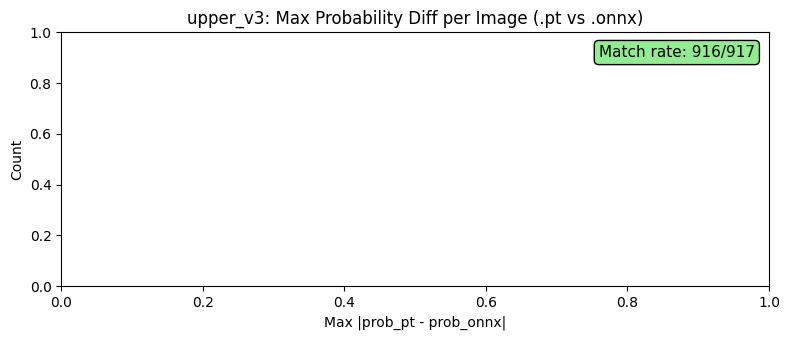

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
test_roots = {
    "test1_13_14th": TEST_ROOT_1,
    "test2_careys": TEST_ROOT_2,
}

upper_results = verify_model("upper_v3", MODELS["upper_v3"], test_roots)

In [ ]:
print("\n" + "=" * 70)
print("  ONNX VERIFICATION SUMMARY")
print("=" * 70)

all_pass = True

for model_name, results in [("upper_v3", upper_results)]:
    print(f"\n  {model_name}:")
    for test_name, r in results.items():
        status = "✓" if r["match_rate"] >= 99.5 else "⚠"
        if r["match_rate"] < 99.5:
            all_pass = False
        print(f"    {status} {test_name}: {r['n_match']}/{r['n_total']} match "
              f"({r['match_rate']:.2f}%) | "
              f"F1: .pt={r['pt_f1']:.4f} .onnx={r['ort_f1']:.4f} (Δ={r['ort_f1']-r['pt_f1']:+.4f}) | "
              f"max_prob_diff={r['max_prob_diff']:.6f}")

print(f"\n{'='*70}")
if all_pass:
    print("  ✓ ALL MODELS VERIFIED — safe to proceed to TensorRT conversion")
else:
    print("  ⚠ SOME MODELS HAVE MISMATCHES — review before TRT conversion")
print("=" * 70)


  ONNX VERIFICATION SUMMARY

  upper_v3:
    ✓ test1_13_14th: 621/621 match (100.00%) | F1: .pt=0.8692 .onnx=0.8692 (Δ=+0.0000) | max_prob_diff=0.005640
    ✓ test2_careys: 295/296 match (99.66%) | F1: .pt=0.7764 .onnx=0.7784 (Δ=+0.0020) | max_prob_diff=0.005323

  ✓ ALL MODELS VERIFIED — safe to proceed to TensorRT conversion


In [ ]:
import os
import json
import time
import numpy as np
from pathlib import Path

import torch
import timm
import onnx
import onnxruntime as ort

# ============================================================
# PATHS & CONFIGURATION
# ============================================================
UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")

MODELS = {
    "upper_v3": {
        "model_name": "upper_v3",
        "ckpt": UPPER_DIR / "best_upper_cnn.pth",
        "backbone": "convnextv2_tiny",
        "img_size": 448,
        "classes": ["blazer", "dresses", "fleece", "jumpers", "shirt", "t-shirt"],
        "onnx_out": UPPER_DIR / "upper_v3.onnx",
        "thresholds": UPPER_DIR / "upper_per_class_thresholds.json",
    }
}

OPSET = 17
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EXPORT_BATCH = 4
VERIFY_BATCHES = [1, 4]

# Verify all checkpoints exist
print("Checking model paths:")
for name, cfg in MODELS.items():
    assert cfg["ckpt"].exists(), f"Missing checkpoint: {cfg['ckpt']}"
    print(f"✓ {name}: {cfg['ckpt'].name} ({cfg['backbone']}, {cfg['img_size']}px, {len(cfg['classes'])} classes)")


# ============================================================
# HELPERS
# ============================================================
def load_pytorch_model(cfg):
    """Load a trained PyTorch model from checkpoint."""
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model, ckpt


def inspect_onnx_io(onnx_path: Path):
    """Print ONNX input/output shapes."""
    model = onnx.load(str(onnx_path))

    def shape_of(value_info):
        dims = []
        for d in value_info.type.tensor_type.shape.dim:
            if d.dim_param:
                dims.append(d.dim_param)
            elif d.dim_value:
                dims.append(d.dim_value)
            else:
                dims.append("?")
        return dims

    print("\n  ONNX I/O:")
    for x in model.graph.input:
        print(f"    Input  {x.name}: {shape_of(x)}")
    for x in model.graph.output:
        print(f"    Output {x.name}: {shape_of(x)}")


def export_to_onnx(model, cfg, opset=17):
    """Export PyTorch model to ONNX with dynamic batch size."""
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    # IMPORTANT: export with batch > 1
    dummy = torch.randn(EXPORT_BATCH, 3, img_size, img_size, device=DEVICE)

    print(f"  Exporting to: {onnx_path}")
    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=opset,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={
            "input": {0: "batch_size"},
            "logits": {0: "batch_size"},
        },
        do_constant_folding=True,
    )

    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    inspect_onnx_io(onnx_path)
    return onnx_path


def simplify_onnx(onnx_path: Path):
    """Simplify ONNX graph. Often helps TRT with ForeignNode issues."""
    sim_path = onnx_path.with_name(onnx_path.stem + "_sim.onnx")

    try:
        import onnxsim
        print(f"  Simplifying ONNX → {sim_path}")
        model = onnx.load(str(onnx_path))
        sim_model, check = onnxsim.simplify(model)

        if not check:
            print("  ⚠ onnxsim validation failed; keeping original ONNX")
            return onnx_path

        onnx.save(sim_model, str(sim_path))
        size_mb = os.path.getsize(sim_path) / (1024 * 1024)
        print(f"  ✓ Simplified ONNX saved — {size_mb:.1f} MB")
        return sim_path

    except ImportError:
        print("  ⚠ onnxsim not installed; skipping simplification")
        return onnx_path
    except Exception as e:
        print(f"  ⚠ ONNX simplification failed: {e}")
        return onnx_path


def validate_onnx(model, cfg, onnx_path: Path):
    """Compare PyTorch vs ONNX Runtime outputs for batch 1 and batch 4."""
    img_size = cfg["img_size"]

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(onnx_path), providers=providers)

    print(f"  Active providers: {session.get_providers()}")

    for batch_size in VERIFY_BATCHES:
        dummy = torch.randn(batch_size, 3, img_size, img_size, device=DEVICE)

        with torch.no_grad():
            pt_logits = model(dummy).detach().cpu().numpy()

        ort_logits = session.run(
            ["logits"],
            {"input": dummy.detach().cpu().numpy()}
        )[0]

        max_diff = np.abs(pt_logits - ort_logits).max()
        mean_diff = np.abs(pt_logits - ort_logits).mean()
        pt_pred = pt_logits.argmax(1)
        ort_pred = ort_logits.argmax(1)
        preds_match = bool((pt_pred == ort_pred).all())

        print(f"\n  Batch {batch_size} validation:")
        print(f"    PyTorch shape: {pt_logits.shape}")
        print(f"    ONNX shape:    {ort_logits.shape}")
        print(f"    Max  abs diff: {max_diff:.8f}")
        print(f"    Mean abs diff: {mean_diff:.8f}")
        print(f"    Predictions match: {preds_match}")

        if max_diff < 1e-4:
            print("    ✓ Outputs match within tolerance")
        else:
            print("    ⚠ Outputs differ beyond 1e-4 — inspect export")

    return session


def benchmark_onnx(cfg, onnx_path: Path, batch_size=1, n_warmup=10, n_runs=50):
    """Benchmark ONNX Runtime latency."""
    img_size = cfg["img_size"]

    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
    session = ort.InferenceSession(str(onnx_path), providers=providers)

    active = session.get_providers()
    print(f"  Active providers: {active}")

    dummy_np = np.random.randn(batch_size, 3, img_size, img_size).astype(np.float32)

    for _ in range(n_warmup):
        session.run(["logits"], {"input": dummy_np})

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        session.run(["logits"], {"input": dummy_np})
        times.append((time.perf_counter() - t0) * 1000)

    times = np.array(times)
    print(
        f"  Latency (ms): mean={times.mean():.1f}, median={np.median(times):.1f}, "
        f"p95={np.percentile(times, 95):.1f}, min={times.min():.1f}, max={times.max():.1f}"
    )
    print(f"  Throughput: ~{1000 / times.mean() * batch_size:.0f} img/s (batch={batch_size})")

    return times


def make_trt_commands(cfg, onnx_path: Path):
    img_size = cfg["img_size"]
    stem = onnx_path.stem

    fp16 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp16.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--fp16 --verbose"
    )
    fp32 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp32.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--verbose"
    )
    return fp16, fp32


# ============================================================
# EXECUTION BLOCK
# ============================================================
print("\n" + "=" * 60)
print("  UPPER V3 — ConvNeXt-V2-Tiny (448px) - ONNX Export & Validation")
print("=" * 60)

cfg = MODELS["upper_v3"]

print(f"\nLoading PyTorch model for {cfg['model_name']} from: {cfg['ckpt']}")
upper_model, ckpt = load_pytorch_model(cfg)

print(f"\nExporting {cfg['model_name']} model to ONNX...")
onnx_path = export_to_onnx(upper_model, cfg, opset=OPSET)

print("\nSimplifying ONNX for TRT...")
onnx_path_for_trt = simplify_onnx(onnx_path)

print(f"\nValidating ONNX output for {cfg['model_name']}...")
validate_onnx(upper_model, cfg, onnx_path_for_trt)

print(f"\nBenchmarking ONNX Runtime for {cfg['model_name']} (batch=1)...")
benchmark_onnx(cfg, onnx_path_for_trt, batch_size=1)

print(f"\nBenchmarking ONNX Runtime for {cfg['model_name']} (batch=4)...")
benchmark_onnx(cfg, onnx_path_for_trt, batch_size=4)

# ============================================================
# METADATA
# ============================================================
thresholds = {}
if cfg["thresholds"].exists():
    with open(cfg["thresholds"]) as f:
        tdata = json.load(f)
    thresholds = tdata.get("thresholds", {})

fp16_cmd, fp32_cmd = make_trt_commands(cfg, onnx_path_for_trt)

meta = {
    "model_name": cfg["model_name"],
    "backbone": cfg["backbone"],
    "onnx_file": onnx_path_for_trt.name,
    "opset": OPSET,
    "input_name": "input",
    "output_name": "logits",
    "input_shape": ["N", 3, cfg["img_size"], cfg["img_size"]],
    "output_shape": ["N", len(cfg["classes"])],
    "dynamic_batch": True,
    "classes": cfg["classes"],
    "num_classes": len(cfg["classes"]),
    "preprocessing": {
        "resize": [cfg["img_size"], cfg["img_size"]],
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
        "channel_order": "RGB",
        "tensor_format": "NCHW",
        "dtype": "float32",
    },
    "thresholds": thresholds,
    "training_info": {
        "best_f1": ckpt.get("best_f1"),
    },
    "trt_conversion": {
        "fp16_command": fp16_cmd,
        "fp32_command": fp32_cmd,
        "note": "Use explicit dynamic shape profiles for batch 1..4.",
    },
}

meta_path = cfg["onnx_out"].with_suffix(".json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("\n" + "=" * 60)
print("  EXPORT SUMMARY")
print("=" * 60)
size_mb = os.path.getsize(onnx_path_for_trt) / (1024 * 1024)

print(f"\n  {cfg['model_name']}:")
print(f"    ONNX:      {onnx_path_for_trt} ({size_mb:.1f} MB)")
print(f"    Metadata:  {meta_path}")
print(f"    Backbone:  {cfg['backbone']}")
print(f"    Input:     [batch, 3, {cfg['img_size']}, {cfg['img_size']}]")
print(f"    Classes:   {cfg['classes']}")
print(f"    TRT FP16:  {fp16_cmd}")
print(f"    TRT FP32:  {fp32_cmd}")

print("\n" + "=" * 60)
print("  All ONNX export, validation, and benchmarking complete!")
print("=" * 60)

Checking model paths:
✓ upper_v3: best_upper_cnn.pth (convnextv2_tiny, 448px, 6 classes)

  UPPER V3 — ConvNeXt-V2-Tiny (448px) - ONNX Export & Validation

Loading PyTorch model for upper_v3 from: /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/best_upper_cnn.pth
  Loaded: convnextv2_tiny — 27.9M params
  Best F1 (train): 0.9083172941361534

Exporting upper_v3 model to ONNX...
  Exporting to: /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper_v3.onnx


/tmp/ipykernel_620/875328565.py:94: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0312 14:55:44.141000 620 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0312 14:55:45.162000 620 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, align

[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ConvNeXt([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Translate the graph into ONNX... ✅


Applied 2 of general pattern rewrite rules.
  ✓ ONNX valid — 0.9 MB
  Opset: 17
  Input:  input  → [batch, 3, 448, 448]
  Output: logits → [batch, 6]

  ONNX I/O:
    Input  input: ['batch_size', 3, 448, 448]
    Output logits: ['batch_size', 6]

Simplifying ONNX for TRT...
  ⚠ onnxsim not installed; skipping simplification

Validating ONNX output for upper_v3...


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


  Active providers: ['CPUExecutionProvider']

  Batch 1 validation:
    PyTorch shape: (1, 6)
    ONNX shape:    (1, 6)
    Max  abs diff: 0.00053734
    Mean abs diff: 0.00026162
    Predictions match: True
    ⚠ Outputs differ beyond 1e-4 — inspect export

  Batch 4 validation:
    PyTorch shape: (4, 6)
    ONNX shape:    (4, 6)
    Max  abs diff: 0.00058921
    Mean abs diff: 0.00014424
    Predictions match: True
    ⚠ Outputs differ beyond 1e-4 — inspect export

Benchmarking ONNX Runtime for upper_v3 (batch=1)...
  Active providers: ['CPUExecutionProvider']
  Latency (ms): mean=144.1, median=140.9, p95=162.5, min=138.6, max=175.7
  Throughput: ~7 img/s (batch=1)

Benchmarking ONNX Runtime for upper_v3 (batch=4)...
  Active providers: ['CPUExecutionProvider']
  Latency (ms): mean=679.3, median=653.7, p95=779.7, min=639.9, max=790.1
  Throughput: ~6 img/s (batch=4)

  EXPORT SUMMARY

  upper_v3:
    ONNX:      /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper

In [ ]:
!pip install onnx onnxruntime onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.0 MB/s eta 0:00:00


In [ ]:
import os
import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import timm
import onnx
import onnxruntime as ort

# ============================================================
# CONFIG
# ============================================================
UPPER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus")
LOWER_DIR = Path("/content/drive/MyDrive/October_27th/model_outputs/lower_v3_base_run")

MODELS = {
    "upper_v3": {
        "model_name": "upper_v3",
        "ckpt": UPPER_DIR / "best_upper_cnn.pth",
        "backbone": "convnextv2_tiny",
        "img_size": 448,
        "classes": ["blazer", "dresses", "fleece", "jumpers", "shirt", "t-shirt"],
        "onnx_out": UPPER_DIR / "upper_v3_trt.onnx",
        "thresholds": UPPER_DIR / "upper_per_class_thresholds.json",
    },
    "lower_v3": {
        "model_name": "lower_v3",
        "ckpt": LOWER_DIR / "best_lower_cnn.pth",
        "backbone": "convnextv2_base.fcmae_ft_in22k_in1k_384",
        "img_size": 384,
        "classes": ["jeans", "jogging_bottoms", "skirts", "trousers"],
        "onnx_out": LOWER_DIR / "lower_v3_trt.onnx",
        "thresholds": LOWER_DIR / "lower_per_class_thresholds.json",
    },
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OPSET = 17
EXPORT_BATCH = 4
VERIFY_BATCHES = [1, 4]


# ============================================================
# WRAPPER
# ============================================================
class TRTExportWrapper(nn.Module):
    """Simple forward path for tracing -> ONNX export."""
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)


# ============================================================
# HELPERS
# ============================================================
def load_pytorch_model(cfg):
    ckpt = torch.load(cfg["ckpt"], map_location=DEVICE, weights_only=False)

    model = timm.create_model(
        cfg["backbone"],
        pretrained=False,
        num_classes=len(cfg["classes"])
    )
    model.load_state_dict(ckpt["model_state"], strict=True)
    model.to(DEVICE)
    model.eval()

    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  Loaded: {cfg['backbone']} — {n_params:.1f}M params")
    print(f"  Best F1 (train): {ckpt.get('best_f1', 'N/A')}")
    return model, ckpt


def get_shape(value_info):
    dims = []
    for d in value_info.type.tensor_type.shape.dim:
        if d.dim_param:
            dims.append(d.dim_param)
        elif d.dim_value:
            dims.append(d.dim_value)
        else:
            dims.append("?")
    return dims


def inspect_onnx_io(onnx_path: Path):
    model = onnx.load(str(onnx_path))
    print("\n  ONNX I/O:")
    for x in model.graph.input:
        print(f"    Input  {x.name}: {get_shape(x)}")
    for x in model.graph.output:
        print(f"    Output {x.name}: {get_shape(x)}")


def print_onnx_op_histogram(onnx_path: Path):
    model = onnx.load(str(onnx_path))
    ops = {}
    for node in model.graph.node:
        ops[node.op_type] = ops.get(node.op_type, 0) + 1

    print("\n  ONNX op histogram:")
    for op in sorted(ops):
        print(f"    {op}: {ops[op]}")


def find_bad_ops(onnx_path: Path, bad_ops=("Loop", "SequenceEmpty", "If")):
    model = onnx.load(str(onnx_path))
    return sorted(set(node.op_type for node in model.graph.node if node.op_type in bad_ops))


def export_to_onnx_traced(model, cfg, opset=17):
    img_size = cfg["img_size"]
    onnx_path = cfg["onnx_out"]

    wrapper = TRTExportWrapper(model).to(DEVICE).eval()
    dummy = torch.randn(EXPORT_BATCH, 3, img_size, img_size, device=DEVICE)

    print("  Tracing model with torch.jit.trace...")
    with torch.no_grad():
        traced = torch.jit.trace(wrapper, dummy, strict=False).eval()
        _ = traced(dummy)

    print(f"  Exporting traced model to: {onnx_path}")
    with torch.no_grad():
        torch.onnx.export(
            traced,
            dummy,
            str(onnx_path),
            opset_version=opset,
            input_names=["input"],
            output_names=["logits"],
            dynamic_axes={
                "input": {0: "batch_size"},
                "logits": {0: "batch_size"},
            },
            export_params=True,
            do_constant_folding=True,
            training=torch.onnx.TrainingMode.EVAL,
            keep_initializers_as_inputs=False,
            dynamo=False,
        )

    onnx_model = onnx.load(str(onnx_path))
    onnx.checker.check_model(onnx_model)

    size_mb = os.path.getsize(onnx_path) / (1024 * 1024)
    print(f"  ✓ ONNX valid — {size_mb:.1f} MB")
    print(f"  Opset: {opset}")
    print(f"  Input:  input  → [batch, 3, {img_size}, {img_size}]")
    print(f"  Output: logits → [batch, {len(cfg['classes'])}]")

    inspect_onnx_io(onnx_path)
    print_onnx_op_histogram(onnx_path)

    bad = find_bad_ops(onnx_path)
    print(f"  Problematic ops before simplification: {bad if bad else 'None'}")

    return onnx_path


def simplify_onnx(onnx_path: Path):
    sim_path = onnx_path.with_name(onnx_path.stem + "_sim.onnx")

    try:
        import onnxsim
        print(f"\n  Simplifying ONNX → {sim_path}")
        model = onnx.load(str(onnx_path))
        sim_model, check = onnxsim.simplify(model)

        if not check:
            print("  ⚠ onnxsim validation failed; keeping original ONNX")
            return onnx_path

        onnx.save(sim_model, str(sim_path))
        size_mb = os.path.getsize(sim_path) / (1024 * 1024)
        print(f"  ✓ Simplified ONNX saved — {size_mb:.1f} MB")

        print_onnx_op_histogram(sim_path)
        bad = find_bad_ops(sim_path)
        print(f"  Problematic ops after simplification: {bad if bad else 'None'}")

        return sim_path

    except ImportError:
        print("  ⚠ onnxsim not installed; skipping simplification")
        return onnx_path
    except Exception as e:
        print(f"  ⚠ ONNX simplification failed: {e}")
        return onnx_path


def validate_onnx(model, cfg, onnx_path: Path):
    img_size = cfg["img_size"]
    session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
    print(f"  Active providers: {session.get_providers()}")

    for batch_size in VERIFY_BATCHES:
        dummy = torch.randn(batch_size, 3, img_size, img_size, device=DEVICE)

        with torch.no_grad():
            pt_logits = model(dummy).detach().cpu().numpy()

        ort_logits = session.run(
            ["logits"],
            {"input": dummy.detach().cpu().numpy()}
        )[0]

        max_diff = np.abs(pt_logits - ort_logits).max()
        mean_diff = np.abs(pt_logits - ort_logits).mean()
        preds_match = bool((pt_logits.argmax(1) == ort_logits.argmax(1)).all())

        print(f"\n  Batch {batch_size} validation:")
        print(f"    PyTorch shape: {pt_logits.shape}")
        print(f"    ONNX shape:    {ort_logits.shape}")
        print(f"    Max  abs diff: {max_diff:.8f}")
        print(f"    Mean abs diff: {mean_diff:.8f}")
        print(f"    Predictions match: {preds_match}")

    return session


def make_trt_commands(cfg, onnx_path: Path):
    img_size = cfg["img_size"]
    stem = onnx_path.stem

    fp16 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp16.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--fp16 --verbose"
    )
    fp32 = (
        f"trtexec --onnx={onnx_path.name} "
        f"--saveEngine={stem}_fp32.engine "
        f"--minShapes=input:1x3x{img_size}x{img_size} "
        f"--optShapes=input:4x3x{img_size}x{img_size} "
        f"--maxShapes=input:4x3x{img_size}x{img_size} "
        f"--verbose"
    )
    return fp16, fp32


# ============================================================
# MAIN
# ============================================================
for name, cfg in MODELS.items():
    print("\n" + "=" * 70)
    print(f"  {cfg['model_name']} — TRT-safe CNN export")
    print("=" * 70)

    model, ckpt = load_pytorch_model(cfg)
    print()

    onnx_path = export_to_onnx_traced(model, cfg, opset=OPSET)
    print()

    onnx_path_for_trt = simplify_onnx(onnx_path)
    print()

    bad_ops = find_bad_ops(onnx_path_for_trt)
    print(f"  Final problematic ops: {bad_ops if bad_ops else 'None'}")
    if bad_ops:
        raise RuntimeError(
            f"{cfg['model_name']} export still contains TRT-unfriendly ops: {bad_ops}"
        )

    validate_onnx(model, cfg, onnx_path_for_trt)
    print()

    thresholds = {}
    if cfg["thresholds"].exists():
        with open(cfg["thresholds"]) as f:
            thresholds = json.load(f).get("thresholds", {})

    fp16_cmd, fp32_cmd = make_trt_commands(cfg, onnx_path_for_trt)

    meta = {
        "model_name": cfg["model_name"],
        "backbone": cfg["backbone"],
        "onnx_file": onnx_path_for_trt.name,
        "opset": OPSET,
        "input_name": "input",
        "output_name": "logits",
        "input_shape": ["N", 3, cfg["img_size"], cfg["img_size"]],
        "output_shape": ["N", len(cfg["classes"])],
        "dynamic_batch": True,
        "classes": cfg["classes"],
        "num_classes": len(cfg["classes"]),
        "thresholds": thresholds,
        "training_info": {
            "best_f1": ckpt.get("best_f1"),
        },
        "trt_conversion": {
            "fp16_command": fp16_cmd,
            "fp32_command": fp32_cmd,
            "note": "Exported with torch.jit.trace + standard torch.onnx.export + opset 17.",
        },
    }

    meta_path = cfg["onnx_out"].with_suffix(".json")
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"\n  TRT FP16: {fp16_cmd}")
    print(f"  TRT FP32: {fp32_cmd}")
    print(f"  Metadata: {meta_path}")



  upper_v3 — TRT-safe CNN export
  Loaded: convnextv2_tiny — 27.9M params
  Best F1 (train): 0.9083172941361534

  Tracing model with torch.jit.trace...
  Exporting traced model to: /content/drive/MyDrive/October_27th/model_outputs/upper_v3_run_opus/upper_v3_trt.onnx


/tmp/ipykernel_620/322687561.py:131: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


  ✓ ONNX valid — 106.4 MB
  Opset: 17
  Input:  input  → [batch, 3, 448, 448]
  Output: logits → [batch, 6]

  ONNX I/O:
    Input  input: ['batch_size', 3, 448, 448]
    Output logits: ['batch_size', 6]

  ONNX op histogram:
    Add: 126
    Constant: 90
    Conv: 22
    Div: 36
    Erf: 18
    Flatten: 1
    Gemm: 1
    GlobalAveragePool: 1
    LayerNormalization: 23
    MatMul: 36
    Mul: 90
    ReduceL2: 18
    ReduceMean: 18
    Transpose: 46
  Problematic ops before simplification: None

  ⚠ onnxsim not installed; skipping simplification

  Final problematic ops: None
  Active providers: ['CPUExecutionProvider']

  Batch 1 validation:
    PyTorch shape: (1, 6)
    ONNX shape:    (1, 6)
    Max  abs diff: 0.00072140
    Mean abs diff: 0.00029632
    Predictions match: True

  Batch 4 validation:
    PyTorch shape: (4, 6)
    ONNX shape:    (4, 6)
    Max  abs diff: 0.00030142
    Mean abs diff: 0.00012815
    Predictions match: True


  TRT FP16: trtexec --onnx=upper_v3_trt.onnx 

In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import timm
import onnx
import onnxruntime as ort

CHECKPOINT_PATH = "/content/drive/Shareddrives/Garment Type/Complete_dataset/model_comparison_18th/DINOv3_ViT_Base_best.pt"
ONNX_OUTPUT = "/content/drive/Shareddrives/Garment Type/Complete_dataset/model_comparison_18th/DINOv3_ViT_Base_trt_dynamo.onnx"

MODEL_ID = "vit_base_patch16_dinov3.lvd1689m"
IMG_SIZE = 384
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OPSET_VERSION = 18
EXPORT_BATCH = 2


class ClassifierHead(nn.Module):
    def __init__(self, hidden_size, num_classes, dropout_rate=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        return self.fc(self.dropout(x))


class DINOv3TRTWrapper(nn.Module):
    """
    Use forward_features and keep the exported graph minimal.
    Export logits only.
    """
    def __init__(self, vision_model, classifier):
        super().__init__()
        self.vision_model = vision_model
        self.classifier = classifier

    def forward(self, pixel_values):
        feats = self.vision_model.forward_features(pixel_values)

        if isinstance(feats, dict):
            if "x_norm_clstoken" in feats:
                feats = feats["x_norm_clstoken"]
            elif "x_cls" in feats:
                feats = feats["x_cls"]
            elif "x" in feats:
                feats = feats["x"]
            else:
                raise RuntimeError(f"Unexpected forward_features dict keys: {list(feats.keys())}")

        if isinstance(feats, (tuple, list)):
            feats = feats[0]

        if feats.dim() == 3:
            feats = feats[:, 0]

        return self.classifier(feats)


def print_io_shapes(onnx_path):
    model = onnx.load(onnx_path)

    def shape_of(value_info):
        dims = []
        for d in value_info.type.tensor_type.shape.dim:
            if d.dim_param:
                dims.append(d.dim_param)
            elif d.dim_value:
                dims.append(d.dim_value)
            else:
                dims.append("?")
        return dims

    print("\nONNX I/O shapes:")
    for x in model.graph.input:
        print(f"  INPUT  {x.name}: {shape_of(x)}")
    for x in model.graph.output:
        print(f"  OUTPUT {x.name}: {shape_of(x)}")


def print_onnx_nodes(onnx_path):
    model = onnx.load(onnx_path)
    ops = {}
    for node in model.graph.node:
        ops[node.op_type] = ops.get(node.op_type, 0) + 1

    print("\nONNX op histogram:")
    for k in sorted(ops):
        print(f"  {k}: {ops[k]}")


def get_bad_ops(onnx_path, bad=("If", "Loop", "SequenceEmpty")):
    model = onnx.load(onnx_path)
    return sorted(set(node.op_type for node in model.graph.node if node.op_type in bad))


def simplify_onnx(onnx_path):
    sim_path = onnx_path.replace(".onnx", "_sim.onnx")
    try:
        import onnxsim
        print("\nSimplifying ONNX...")
        model = onnx.load(onnx_path)
        sim_model, check = onnxsim.simplify(model)
        if check:
            onnx.save(sim_model, sim_path)
            print(f"  Saved simplified ONNX: {sim_path}")
            return sim_path
        print("  onnxsim check failed; using original ONNX")
        return onnx_path
    except Exception as e:
        print(f"  onnxsim skipped: {e}")
        return onnx_path


def main():
    print("=" * 60)
    print("DINOv3 TRT-safe export via dynamo exporter")
    print("=" * 60)

    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
    hidden_size = ckpt["hidden_size"]

    vision_model = timm.create_model(MODEL_ID, pretrained=False, num_classes=0)
    vision_model.load_state_dict(ckpt["vision_model"])
    vision_model = vision_model.to(DEVICE).eval()

    classifier = ClassifierHead(hidden_size, NUM_CLASSES, dropout_rate=0.0)
    classifier.load_state_dict(ckpt["classifier"])
    classifier = classifier.to(DEVICE).eval()

    model = DINOv3TRTWrapper(vision_model, classifier).to(DEVICE).eval()

    dummy = torch.randn(EXPORT_BATCH, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

    with torch.no_grad():
        ref = model(dummy)
    print("PyTorch output shape:", tuple(ref.shape))

    os.makedirs(os.path.dirname(ONNX_OUTPUT), exist_ok=True)

    # New exporter
    torch.onnx.export(
        model,
        (dummy,),
        ONNX_OUTPUT,
        opset_version=OPSET_VERSION,
        input_names=["pixel_values"],
        output_names=["logits"],
        dynamic_axes={
            "pixel_values": {0: "batch"},
            "logits": {0: "batch"},
        },
        dynamo=True,
    )

    onnx_model = onnx.load(ONNX_OUTPUT)
    onnx.checker.check_model(onnx_model)

    print(f"Saved ONNX: {ONNX_OUTPUT}")
    print_io_shapes(ONNX_OUTPUT)
    print_onnx_nodes(ONNX_OUTPUT)

    bad_before = get_bad_ops(ONNX_OUTPUT)
    print("Problematic ops before simplification:", bad_before if bad_before else "None")

    final_onnx = simplify_onnx(ONNX_OUTPUT)

    bad_after = get_bad_ops(final_onnx)
    print("Problematic ops after simplification:", bad_after if bad_after else "None")

    if "If" in bad_after:
        raise RuntimeError(
            "Dynamo export still contains If. This backbone path is not yet TRT-safe."
        )

    sess = ort.InferenceSession(final_onnx, providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    ort_out = sess.run(["logits"], {"pixel_values": dummy.detach().cpu().numpy()})[0]

    diff = np.max(np.abs(ref.detach().cpu().numpy() - ort_out))
    print("Max PT-ORT diff:", float(diff))

    print("\nTRT build command:")
    print(
        f"trtexec --onnx={final_onnx} "
        f"--saveEngine=DINOv3_ViT_Base_trt_fp16.engine "
        f"--minShapes=pixel_values:1x3x{IMG_SIZE}x{IMG_SIZE} "
        f"--optShapes=pixel_values:4x3x{IMG_SIZE}x{IMG_SIZE} "
        f"--maxShapes=pixel_values:4x3x{IMG_SIZE}x{IMG_SIZE} "
        f"--fp16 --verbose"
    )


if __name__ == "__main__":
    main()

DINOv3 TRT-safe export via dynamo exporter
PyTorch output shape: (2, 4)


/tmp/ipykernel_620/2940187697.py:144: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0312 15:41:54.359000 620 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0312 15:41:54.361000 620 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0312 15:41:54.363000 620 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0)

[torch.onnx] Obtain model graph for `DINOv3TRTWrapper([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DINOv3TRTWrapper([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 76 of general pattern rewrite rules.
Saved ONNX: /content/drive/Shareddrives/Garment Type/Complete_dataset/model_comparison_18th/DINOv3_ViT_Base_trt_dynamo.onnx

ONNX I/O shapes:
  INPUT  pixel_values: ['batch', 3, 384, 384]
  OUTPUT logits: ['batch', 4]

ONNX op histogram:
  Add: 96
  Concat: 78
  Conv: 1
  Cos: 1
  Div: 12
  Erf: 12
  Expand: 2
  Gather: 1
  Gemm: 1
  LayerNormalization: 25
  MatMul: 72
  Mul: 120
  Neg: 24
  Reshape: 50
  Shape: 13
  Sin: 1
  Slice: 120
  Softmax: 12
  Split: 25
  Squeeze: 36
  Tile: 1
  Transpose: 37
Problematic ops before simplification: None
  onnxsim skipped: No module named 'onnxsim'
Problematic ops after simplification: None


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Max PT-ORT diff: 8.040666580200195e-05

TRT build command:
trtexec --onnx=/content/drive/Shareddrives/Garment Type/Complete_dataset/model_comparison_18th/DINOv3_ViT_Base_trt_dynamo.onnx --saveEngine=DINOv3_ViT_Base_trt_fp16.engine --minShapes=pixel_values:1x3x384x384 --optShapes=pixel_values:4x3x384x384 --maxShapes=pixel_values:4x3x384x384 --fp16 --verbose
